**Imports**

# **V-Plot — Visualizing Protected Fragments**

** Load the Data File  **                        
We load the input .bed.gz file using pandas.read_csv(). The file is tab-separated and has no header, so we set header=None.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Read the input file
file_name = "mapped.bed.gz"
data = pd.read_csv(file_name, sep="\t", header=None)

**Calculate X and Y Values**    
We calculate:
*  C1 is the center of the protein binding site
*   C2 is the center of the sequenced DNA fragment

* X = C2 - C1 tells how far the fragment is from the binding site
*  Y = fragment size

These two will define our 2D heatmap coordinates.

In [ ]:
# Step 2: Extract necessary columns and compute X, Y
X_vals = []
Y_vals = []

for _, row in data.iterrows():
    # C1 = center of protein binding site (col 3 and 4)
    C1 = (row[2] + row[3]) / 2

    # C2 = center of fragment (col 9 and 10)
    C2 = (row[8] + row[9]) / 2

    # X = C2 - C1 (position relative to protein)
    X = C2 - C1

    # Y = Fragment size (col10 - col9)
    Y = row[9] - row[8]

    # Store values
    X_vals.append(X)
    Y_vals.append(Y)

**Count Occurrences (Z)**  
Build a 2D dictionary Z_counts[X][Y] = count, where each cell stores how many times a fragment of size Y appears at distance X from a binding site.

In [ ]:
# Step 3: Create dictionary to count Z = frequency of (X, Y) pairs
Z_counts = {}

for X, Y in zip(X_vals, Y_vals):
    if X not in Z_counts:
        Z_counts[X] = {}
    if Y not in Z_counts[X]:
        Z_counts[X][Y] = 0
    Z_counts[X][Y] += 1


**Build the Heatmap Matrix**
We create


*   X_range: sorted list of all unique X values
*   Y_range: sorted list of all unique fragment sizes
Then we fill a 2D NumPy matrix heatmap_data[j, i] corresponding to (Y, X).



In [50]:
# Step 4: Convert Z_counts to a 2D matrix
X_range = sorted(Z_counts.keys())
Y_range = sorted(set(y for y_dict in Z_counts.values() for y in y_dict.keys()))

# Initialize matrix
heatmap_data = np.zeros((len(Y_range), len(X_range)))

# Fill matrix
for i, X in enumerate(X_range):
    for j, Y in enumerate(Y_range):
        if Y in Z_counts[X]:
            heatmap_data[j, i] = Z_counts[X][Y]


** Plot Heatmap**


*   We plot the 2D matrix using Seaborn’s heatmap.
*  X_range and Y_range are used as tick labels
*   The viridis colormap and colorbar help visually track fragment density.
*   The plot shows where DNA fragments (Y) are found relative to protein-binding sites (X), forming a V shape.

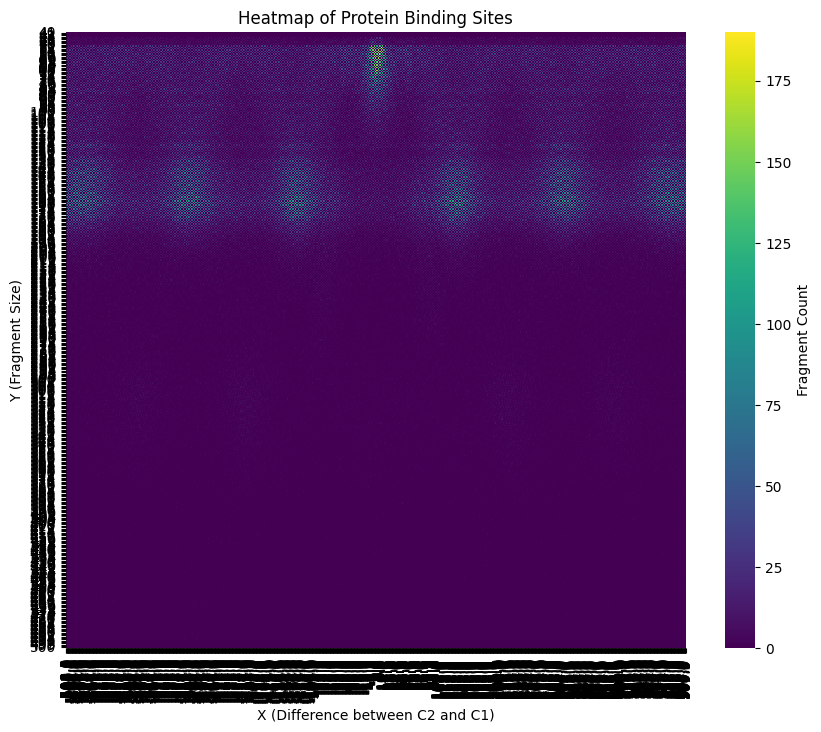

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    xticklabels=X_range,
    yticklabels=Y_range,
    cmap="viridis",
    cbar_kws={'label': 'Fragment Count'}
)
plt.xlabel("X (Difference between C2 and C1)")
plt.ylabel("Y (Fragment Size)")
plt.title("Heatmap of Protein Binding Sites")
plt.show()
